In [ ]:
!pip install skimpy imblearn plotly xgboost catboost causalml econml  hmmlearn mlflow lightgbm pyngrok graphviz pydot

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import skimpy as sk
import plotly.express as px
import plotly.graph_objects as go
from scipy.stats import *
import econml
import econml.dml
import mlflow
import mlflow.sklearn
import causalml
import causalml.inference
from imblearn.over_sampling import SMOTE

from sklearn.preprocessing import *
from sklearn.model_selection import *
from sklearn.metrics import *
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import VotingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

import joblib

In [ ]:
train_df = pd.read_csv("/content/drive/MyDrive/Preprocessed_Data/Women_Preprocessed/women_training_data.csv")
test_df = pd.read_csv("/content/drive/MyDrive/Preprocessed_Data/Women_Preprocessed/women_test_data.csv")
ids = test_df["ID"]

test_df = test_df.drop(columns=["ID"], axis=1)
test_df = test_df[['Season', 'Team1ID', 'Team2ID', 'Team1Name', 'Team2Name',
       'Team1_WinPct', 'Team1_AvgPointsFor', 'Team1_AvgPointsAgainst',
       'Team1_PointDiff', 'Team1_NumGames', 'Team1_Seed', 'Team2_WinPct',
       'Team2_AvgPointsFor', 'Team2_AvgPointsAgainst', 'Team2_PointDiff',
       'Team2_NumGames', 'Team2_Seed', 'H2H_Team1Wins', 'H2H_Team2Wins',
       'Diff_WinPct', 'Diff_PointDiff', 'Diff_Seed', 'SameConference']]

In [ ]:
test_df

,Season,Team1ID,Team2ID,Team1Name,Team2Name,Team1_WinPct,Team1_AvgPointsFor,Team1_AvgPointsAgainst,Team1_PointDiff,Team1_NumGames,...,Team2_AvgPointsAgainst,Team2_PointDiff,Team2_NumGames,Team2_Seed,H2H_Team1Wins,H2H_Team2Wins,Diff_WinPct,Diff_PointDiff,Diff_Seed,SameConference
0,2022.0,3101.0,3102.0,Abilene Chr,Air Force,0.500000,70.923077,70.000000,0.923077,26.0,...,58.896552,2.965517,29.0,16.0,0.0,0.0,-0.051724,-2.042440,0.0,0.0
1,2022.0,3101.0,3103.0,Abilene Chr,Akron,0.500000,70.923077,70.000000,0.923077,26.0,...,67.185185,-0.851852,27.0,16.0,0.0,0.0,-0.092593,1.774929,0.0,0.0
2,2022.0,3101.0,3104.0,Abilene Chr,Alabama,0.500000,70.923077,70.000000,0.923077,26.0,...,65.133333,5.400000,30.0,16.0,0.0,0.0,-0.066667,-4.476923,0.0,0.0
3,2022.0,3101.0,3105.0,Abilene Chr,Alabama A&M,0.500000,70.923077,70.000000,0.923077,26.0,...,62.758621,-3.103448,29.0,16.0,0.0,0.0,-0.017241,4.026525,0.0,0.0
4,2022.0,3101.0,3106.0,Abilene Chr,Alabama St,0.500000,70.923077,70.000000,0.923077,26.0,...,70.000000,-6.793103,29.0,16.0,0.0,0.0,0.017241,7.716180,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
258126,2025.0,3477.0,3479.0,East Texas A&M,Mercyhurst,0.185185,60.888889,72.185185,-11.296296,27.0,...,70.500000,-7.708333,24.0,16.0,0.0,0.0,-0.064815,-3.587963,0.0,0.0
258127,2025.0,3477.0,3480.0,East Texas A&M,West Georgia,0.185185,60.888889,72.185185,-11.296296,27.0,...,70.750000,-5.285714,28.0,16.0,0.0,0.0,-0.207672,-6.010582,0.0,0.0
258128,2025.0,3478.0,3479.0,Le Moyne,Mercyhurst,0.225806,53.870968,68.967742,-15.096774,31.0,...,70.500000,-7.708333,24.0,16.0,1.0,0.0,-0.024194,-7.388441,0.0,1.0
258129,2025.0,3478.0,3480.0,Le Moyne,West Georgia,0.225806,53.870968,68.967742,-15.096774,31.0,...,70.750000,-5.285714,28.0,16.0,0.0,0.0,-0.167051,-9.811060,0.0,0.0


In [ ]:
sk.skim(train_df)

╭──────────────────────────────────────────────── skimpy summary ─────────────────────────────────────────────────╮
│          Data Summary                Data Types                                                                 │
│ ┏━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┓ ┏━━━━━━━━━━━━━┳━━━━━━━┓                                                          │
│ ┃ Dataframe         ┃ Values ┃ ┃ Column Type ┃ Count ┃                                                          │
│ ┡━━━━━━━━━━━━━━━━━━━╇━━━━━━━━┩ ┡━━━━━━━━━━━━━╇━━━━━━━┩                                                          │
│ │ Number of rows    │ 2536   │ │ float64     │ 13    │                                                          │
│ │ Number of columns │ 24     │ │ int64       │ 9     │                                                          │
│ └───────────────────┴────────┘ │ string      │ 2     │                                                          │
│                                └─────────────┴───────┘                                                          │
│                                                     number                                                      │
│ ┏━━━━━━━━━━━━━━━━━━━━━┳━━━━┳━━━━━━┳━━━━━━━━━┳━━━━━━━━┳━━━━━━━━━┳━━━━━━━━━┳━━━━━━━━┳━━━━━━━━┳━━━━━━━━┳━━━━━━━━┓  │
│ ┃ column              ┃ NA ┃ NA % ┃ mean    ┃ sd     ┃ p0      ┃ p25     ┃ p50    ┃ p75    ┃ p100   ┃ hist   ┃  │
│ ┡━━━━━━━━━━━━━━━━━━━━━╇━━━━╇━━━━━━╇━━━━━━━━━╇━━━━━━━━╇━━━━━━━━━╇━━━━━━━━━╇━━━━━━━━╇━━━━━━━━╇━━━━━━━━╇━━━━━━━━┩  │
│ │ Season              │  0 │    0 │    2013 │  6.027 │    2003 │    2008 │   2013 │   2018 │   2023 │ █▆▆█▆▆ │  │
│ │ Team1ID             │  0 │    0 │    3285 │     98 │    3101 │    3203 │   3280 │   3376 │   3462 │ ▄▇█▆█▄ │  │
│ │ Team2ID             │  0 │    0 │    3285 │     98 │    3101 │    3203 │   3280 │   3376 │   3462 │ ▄▇█▆█▄ │  │
│ │ Team1_WinPct        │  0 │    0 │  0.7809 │ 0.1104 │  0.4074 │     0.7 │ 0.7812 │  0.871 │      1 │  ▁▅█▇▄ │  │
│ │ Team1_AvgPointsFor  │  0 │    0 │    72.4 │  6.466 │   53.56 │   67.81 │  71.97 │  76.38 │  91.27 │  ▃█▇▃▁ │  │
│ │ Team1_AvgPointsAgai │  0 │    0 │   59.42 │  5.163 │   45.67 │   55.73 │  59.18 │  62.74 │  80.48 │ ▁▆█▄▁  │  │
│ │ nst                 │    │      │         │        │         │         │        │        │        │        │  │
│ │ Team1_PointDiff     │  0 │    0 │   12.98 │  7.151 │  -5.594 │   8.094 │  12.05 │  16.98 │  42.06 │ ▁▇█▃▁  │  │
│ │ Team1_NumGames      │  0 │    0 │   30.77 │  2.228 │      14 │      30 │     31 │     32 │     34 │     ▄█ │  │
│ │ Team1_Seed          │  0 │    0 │   6.355 │  4.525 │       1 │       2 │      5 │     10 │     16 │ █▃▄▂▃▂ │  │
│ │ Team2_WinPct        │  0 │    0 │  0.7809 │ 0.1104 │  0.4074 │     0.7 │ 0.7812 │  0.871 │      1 │  ▁▅█▇▄ │  │
│ │ Team2_AvgPointsFor  │  0 │    0 │    72.4 │  6.466 │   53.56 │   67.81 │  71.97 │  76.38 │  91.27 │  ▃█▇▃▁ │  │
│ │ Team2_AvgPointsAgai │  0 │    0 │   59.42 │  5.163 │   45.67 │   55.73 │  59.18 │  62.74 │  80.48 │ ▁▆█▄▁  │  │
│ │ nst                 │    │      │         │        │         │         │        │        │        │        │  │
│ │ Team2_PointDiff     │  0 │    0 │   12.98 │  7.151 │  -5.594 │   8.094 │  12.05 │  16.98 │  42.06 │ ▁▇█▃▁  │  │
│ │ Team2_NumGames      │  0 │    0 │   30.77 │  2.228 │      14 │      30 │     31 │     32 │     34 │     ▄█ │  │
│ │ Team2_Seed          │  0 │    0 │   6.355 │  4.525 │       1 │       2 │      5 │     10 │     16 │ █▃▄▂▃▂ │  │
│ │ H2H_Team1Wins       │  0 │    0 │ 0.06625 │ 0.2641 │       0 │       0 │      0 │      0 │      2 │   █    │  │
│ │ H2H_Team2Wins       │  0 │    0 │ 0.03312 │ 0.2187 │       0 │       0 │      0 │      0 │      3 │   █    │  │
│ │ Diff_WinPct         │  0 │    0 │       0 │ 0.1678 │ -0.5484 │ -0.1147 │      0 │ 0.1147 │ 0.5484 │  ▃██▃  │  │
│ │ Diff_PointDiff      │  0 │    0 │       0 │  10.52 │  -41.88 │  -6.201 │      0 │  6.201 │  41.88 │  ▂██▂  │  │
│ │ Diff_Seed           │  0 │    0 │       0 │    7.4 │

In [ ]:
sk.skim(test_df)

╭──────────────────────────────────────────────── skimpy summary ─────────────────────────────────────────────────╮
│          Data Summary                Data Types                                                                 │
│ ┏━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┓ ┏━━━━━━━━━━━━━┳━━━━━━━┓                                                          │
│ ┃ Dataframe         ┃ Values ┃ ┃ Column Type ┃ Count ┃                                                          │
│ ┡━━━━━━━━━━━━━━━━━━━╇━━━━━━━━┩ ┡━━━━━━━━━━━━━╇━━━━━━━┩                                                          │
│ │ Number of rows    │ 258131 │ │ float64     │ 21    │                                                          │
│ │ Number of columns │ 23     │ │ string      │ 2     │                                                          │
│ └───────────────────┴────────┘ └─────────────┴───────┘                                                          │
│                                                     number                                                      │
│ ┏━━━━━━━━━━━━━━━━━━━━━┳━━━━┳━━━━━━┳━━━━━━━━━━┳━━━━━━━━┳━━━━━━━━┳━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━━┓  │
│ ┃ column              ┃ NA ┃ NA % ┃ mean     ┃ sd     ┃ p0     ┃ p25    ┃ p50      ┃ p75    ┃ p100  ┃ hist   ┃  │
│ ┡━━━━━━━━━━━━━━━━━━━━━╇━━━━╇━━━━━━╇━━━━━━━━━━╇━━━━━━━━╇━━━━━━━━╇━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━━┩  │
│ │ Season              │  0 │    0 │     2024 │  1.116 │   2022 │   2023 │     2024 │   2025 │  2025 │ █ █ ██ │  │
│ │ Team1ID             │  0 │    0 │     3228 │  87.81 │   3101 │   3156 │     3213 │   3290 │  3479 │ █▇▆▄▂▁ │  │
│ │ Team2ID             │  0 │    0 │     3352 │  87.72 │   3102 │   3290 │     3368 │   3425 │  3480 │ ▁▂▄▅▇█ │  │
│ │ Team1_WinPct        │  0 │    0 │   0.4966 │ 0.2084 │      0 │ 0.3448 │      0.5 │ 0.6562 │     1 │ ▂▄█▇▅▂ │  │
│ │ Team1_AvgPointsFor  │  0 │    0 │    64.61 │  7.278 │     45 │  59.45 │    63.92 │  69.33 │ 92.85 │ ▁▆█▄▁  │  │
│ │ Team1_AvgPointsAgai │  0 │    0 │    64.73 │  5.622 │  47.46 │  60.93 │     64.5 │  68.33 │ 84.77 │  ▃█▆▁  │  │
│ │ nst                 │    │      │          │        │        │        │          │        │       │        │  │
│ │ Team1_PointDiff     │  0 │    0 │  -0.1182 │  9.115 │ -29.29 │     -6 │     -0.2 │    5.8 │ 30.34 │  ▃█▇▃  │  │
│ │ Team1_NumGames      │  0 │    0 │    29.63 │  2.083 │     22 │     28 │       30 │     31 │    35 │  ▁▄█▆▁ │  │
│ │ Team1_Seed          │  0 │    0 │    14.65 │  3.399 │      1 │     16 │       16 │     16 │    16 │      █ │  │
│ │ Team2_WinPct        │  0 │    0 │   0.4911 │ 0.2092 │      0 │ 0.3448 │   0.4839 │ 0.6452 │     1 │ ▂▅██▅▂ │  │
│ │ Team2_AvgPointsFor  │  0 │    0 │    64.63 │  7.101 │     45 │  59.69 │       64 │  69.11 │ 92.85 │ ▁▅█▄▁  │  │
│ │ Team2_AvgPointsAgai │  0 │    0 │    65.07 │  5.683 │  47.46 │     61 │    64.76 │  69.04 │ 84.77 │  ▄█▇▂  │  │
│ │ nst                 │    │      │          │        │        │        │          │        │       │        │  │
│ │ Team2_PointDiff     │  0 │    0 │  -0.4334 │  9.043 │ -29.29 │ -6.429 │    -0.75 │   5.25 │ 30.34 │  ▃█▇▂  │  │
│ │ Team2_NumGames      │  0 │    0 │    29.56 │  2.068 │     22 │     28 │       30 │     31 │    35 │  ▁▄█▆▁ │  │
│ │ Team2_Seed          │  0 │    0 │    14.63 │  3.547 │      1 │     16 │       16 │     16 │    16 │      █ │  │
│ │ H2H_Team1Wins       │  0 │    0 │  0.02983 │ 0.1701 │      0 │      0 │        0 │      0 │     1 │   █    │  │
│ │ H2H_Team2Wins       │  0 │    0 │  0.02878 │ 0.1672 │      0 │      0 │        0 │      0 │     1 │   █    │  │
│ │ Diff_WinPct         │  0 │    0 │  0.00551 │ 0.2956 │     -1 │   -0.2 │ 0.007407 │ 0.2143 │     1 │  ▃██▃  │  │
│ │ Diff_PointDiff      │  0 │    0 │   0.3151 │  12.86 │ -57.69 │ -8.232 │   0.4545 │      9 │ 52.73 │  ▁▆█▂  │  │
│ │ Diff_Seed           │  0 │    0 │ -0.01782 │  4.919 │    -15 │      0 │        0 │      0 │    15 │ ▁▁▁█▁▁ │  │
│ │ SameConference      │  0 │    0 │  0.02985 │ 0.1702 

In [ ]:
label_encoders = {}
for col in train_df.select_dtypes(include=["object"]).columns:
    le = LabelEncoder()
    train_df[col] = le.fit_transform(train_df[col])
    test_df[col] = le.fit_transform(test_df[col])

## EDA

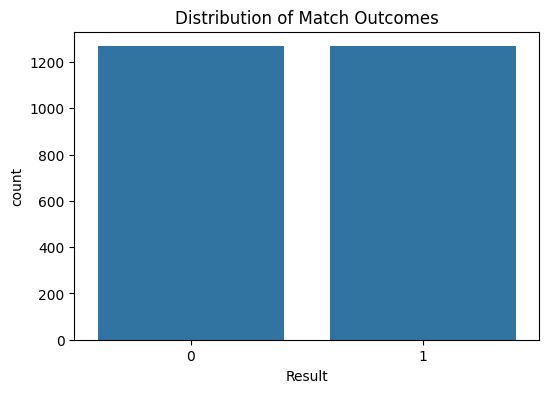

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(data=train_df, x="Result")
plt.title("Distribution of Match Outcomes")
plt.savefig("Outcome")
plt.show()

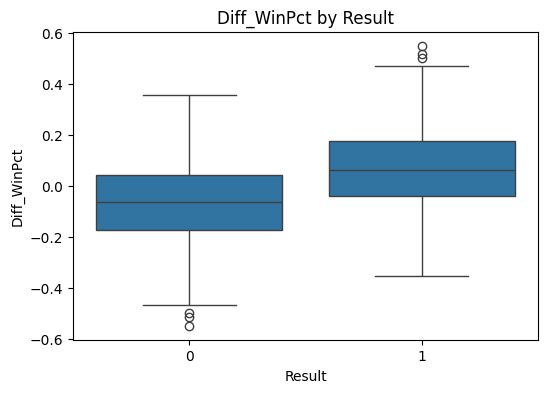

In [ ]:
plt.figure(figsize=(6,4))
sns.boxplot(data=train_df, x="Result", y="Diff_WinPct")
plt.title("Diff_WinPct by Result")
plt.savefig("Diff_WinPct")
plt.show()

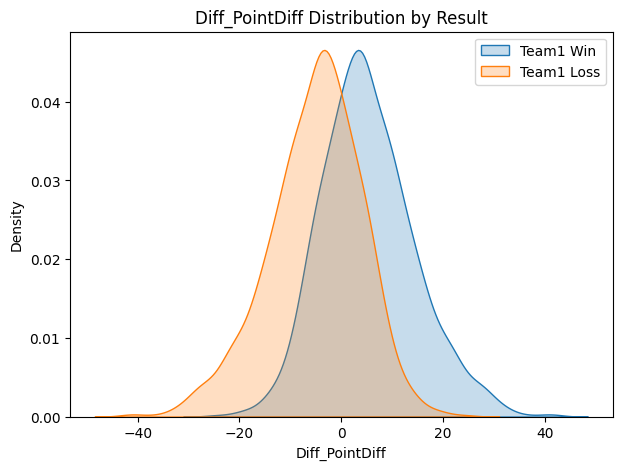

In [ ]:
plt.figure(figsize=(7,5))
sns.kdeplot(data=train_df[train_df["Result"]==1], x="Diff_PointDiff", label="Team1 Win", fill=True)
sns.kdeplot(data=train_df[train_df["Result"]==0], x="Diff_PointDiff", label="Team1 Loss", fill=True)
plt.legend()
plt.title("Diff_PointDiff Distribution by Result")
#plt.savefig("Diff_PointDiff")
plt.show()

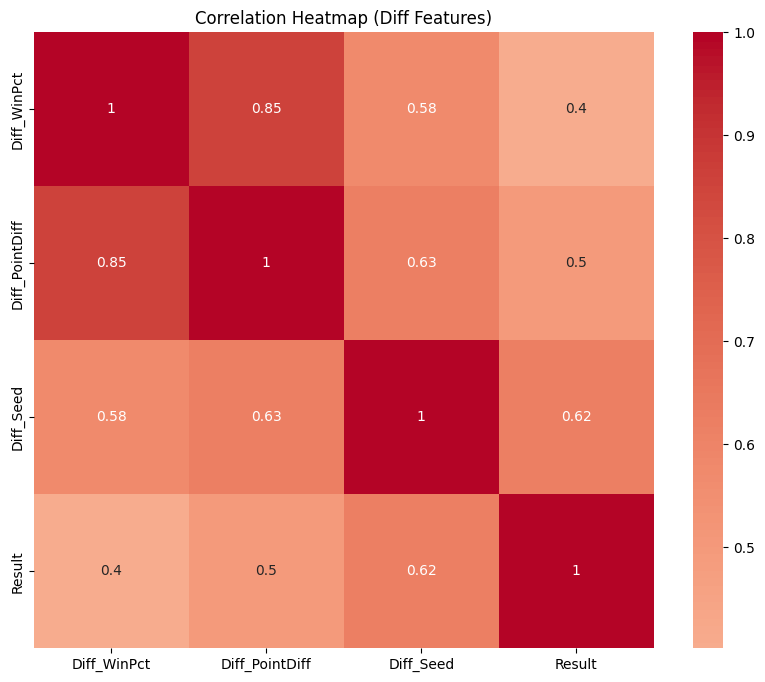

In [ ]:
diff_cols = [col for col in train_df.columns if "Diff_" in col] + ["Result"]

plt.figure(figsize=(10,8))
sns.heatmap(train_df[diff_cols].corr(), annot=True, cmap="coolwarm", center=0)
plt.title("Correlation Heatmap (Diff Features)")
#plt.savefig("Diff_Corr")
plt.show()

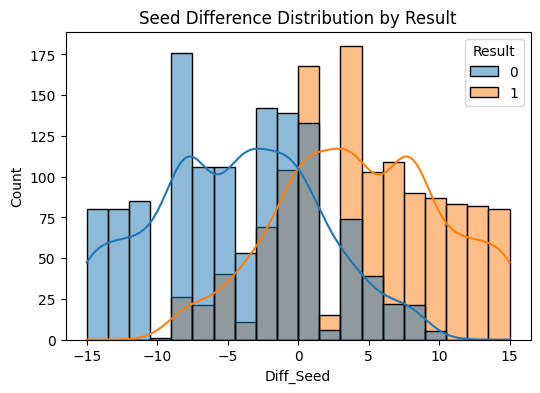

In [ ]:
plt.figure(figsize=(6,4))
sns.histplot(data=train_df, x="Diff_Seed", hue="Result", kde=True, bins=20)
plt.title("Seed Difference Distribution by Result")
#plt.savefig("Seed_Diff")
plt.show()

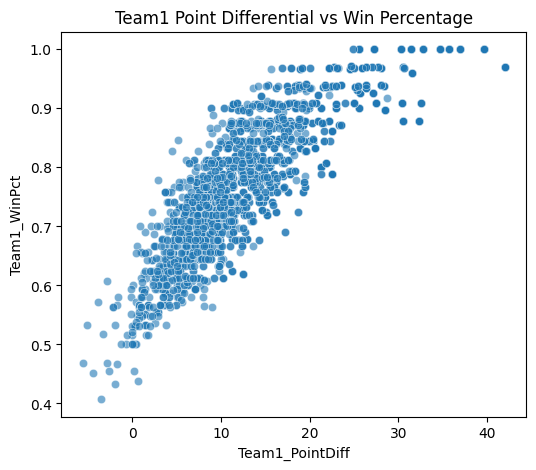

In [ ]:
plt.figure(figsize=(6,5))
sns.scatterplot(data=train_df,
                x="Team1_PointDiff",
                y="Team1_WinPct",
                alpha=0.6)
plt.title("Team1 Point Differential vs Win Percentage")
#plt.savefig("Team1_PointDiff")
plt.show()

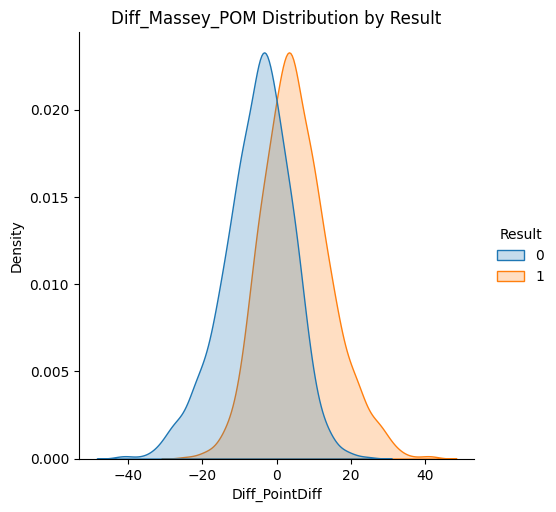

In [ ]:
sns.displot(data=train_df, x="Diff_PointDiff", hue="Result", kind="kde", fill=True)
plt.title("Diff_Massey_POM Distribution by Result")
#plt.savefig("Diff_Massey_POM")
plt.show()

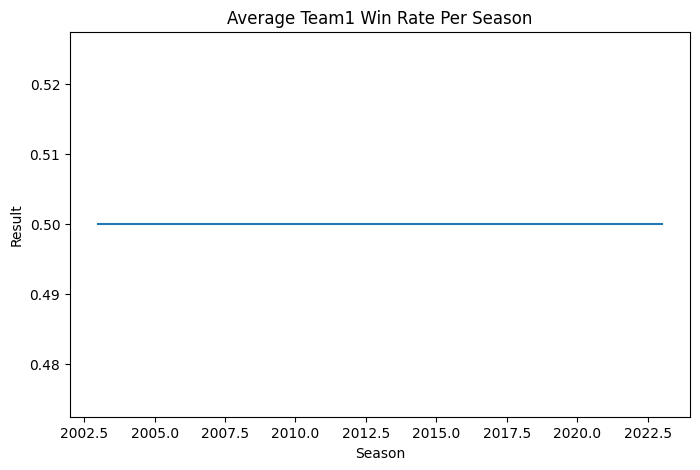

In [ ]:
season_win_rate = train_df.groupby("Season")["Result"].mean().reset_index()

plt.figure(figsize=(8,5))
sns.lineplot(data=season_win_rate, x="Season", y="Result")
plt.title("Average Team1 Win Rate Per Season")
#plt.savefig("Season_WinRate")
plt.show()

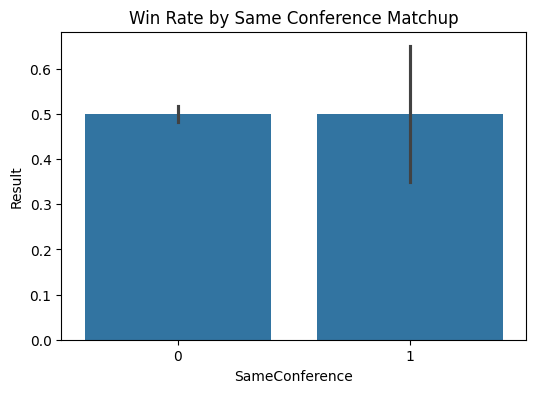

In [ ]:
plt.figure(figsize=(6,4))
sns.barplot(data=train_df, x="SameConference", y="Result")
plt.title("Win Rate by Same Conference Matchup")
#plt.savefig("Win Rate by Same Conference Matchup")
plt.show()

## Modelling

In [ ]:
lr = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
      penalty="l2",
      C=1.0,
      solver="lbfgs",
      max_iter=1000
  ))
])

dt = Pipeline([
    ("scaler", StandardScaler()),
    ("model", DecisionTreeClassifier(
      criterion="gini",
      max_depth=6,
      min_samples_split=10,
      min_samples_leaf=5,
      random_state=42
  ))
])

rf = Pipeline([
    ("scaler", StandardScaler()),
    ("model",RandomForestClassifier(
      n_estimators=300,
      max_depth=None,
      min_samples_split=5,
      min_samples_leaf=2,
      max_features="sqrt",
      bootstrap=True,
      random_state=42,
      n_jobs=-1
  ))
])

gb = Pipeline([
    ("scaler", StandardScaler()),
    ("model", GradientBoostingClassifier(
      n_estimators=200,
      learning_rate=0.05,
      max_depth=3,
      subsample=0.8,
      random_state=42
  ))
])

xgb = Pipeline([
    ("scaler", StandardScaler()),
    ("model", XGBClassifier(
      n_estimators=300,
      learning_rate=0.05,
      max_depth=5,
      subsample=0.8,
      colsample_bytree=0.8,
      min_child_weight=3,
      gamma=0,
      reg_lambda=1,
      objective="binary:logistic",
      eval_metric="logloss",
      use_label_encoder=False,
      random_state=42
  ))
])

lgbm = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LGBMClassifier(
      n_estimators=300,
      learning_rate=0.05,
      num_leaves=31,
      max_depth=-1,
      min_child_samples=20,
      subsample=0.8,
      colsample_bytree=0.8,
      reg_lambda=1.0,
      random_state=42
  ))
])

cat = Pipeline([
    ("scaler", StandardScaler()),
    ("model", CatBoostClassifier(
      iterations=500,
      learning_rate=0.05,
      depth=6,
      l2_leaf_reg=3,
      bootstrap_type="Bernoulli",
      subsample=0.8,
      loss_function="Logloss",
      eval_metric="Logloss",
      random_seed=42,
      verbose=False
  ))
])

## Citations

For Logistic Regression
 - Tibshirani, R. (1996). Regression shrinkage and selection via the lasso. Journal of the Royal Statistical Society: Series B (Methodological), 58(1), 267–288. https://doi.org/10.1111/j.2517-6161.1996.tb02080.x

 - Hastie, T., Tibshirani, R., & Friedman, J. (2009). The elements of statistical learning: Data mining, inference, and prediction (2nd ed.). Springer. https://doi.org/10.1007/978-0-387-84858-7

(Chapter 4 discusses penalized logistic regression and ridge regularization.)

For Decision Tree
- Breiman, L., Friedman, J., Olshen, R., & Stone, C. (1984). Classification and regression trees. Wadsworth International Group.

(Original CART formulation introducing Gini impurity and tree growth principles.)

For Random Forest

- Breiman, L. (2001). Random forests. Machine Learning, 45(1), 5–32. https://doi.org/10.1023/A:1010933404324

(Defines bootstrap aggregation and m_try = √p for classification.)

For GradientBoosting
- Friedman, J. H. (2001). Greedy function approximation: A gradient boosting machine. Annals of Statistics, 29(5), 1189–1232. https://doi.org/10.1214/aos/1013203451

(Shows shrinkage parameter ~0.1 and shallow trees (depth 3–5) as effective boosting configuration.)

For XGBoost
-  Chen, T., & Guestrin, C. (2016). XGBoost: A scalable tree boosting system. In Proceedings of the 22nd ACM SIGKDD International Conference on Knowledge Discovery and Data Mining (pp. 785–794). https://doi.org/10.1145/2939672.2939785

(Describes shrinkage, column subsampling, regularization, and depth effects.)

For LightGBM
- Ke, G., Meng, Q., Finley, T., Wang, T., Chen, W., Ma, W., Ye, Q., & Liu, T.-Y. (2017). LightGBM: A highly efficient gradient boosting decision tree. In Advances in Neural Information Processing Systems, 30.

(Explains leaf-wise tree growth, number of leaves parameter, and boosting configuration.)

For Catboost
- Dorogush, A. V., Ershov, V., & Gulin, A. (2018). CatBoost: Gradient boosting with categorical features support. arXiv preprint arXiv:1810.11363. https://arxiv.org/abs/1810.11363

(Proposes ordered boosting, symmetric trees, depth settings, regularization, and shrinkage strategy.)

In [ ]:
X = train_df.drop(columns=["Result"], axis=1)
y = train_df["Result"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

<Figure size 640x480 with 0 Axes>


Logistic Regression Accuracy: 0.7460629921259843
Logistic Regression Precision: 0.7269230769230769
Logistic Regression Recall: 0.7651821862348178
Logistic Regression F1 Score: 0.7455621301775148
Logistic Regression ROC-AUC: 0.8497836102191819
Logistic Regression Log Loss: 0.47774646984046004


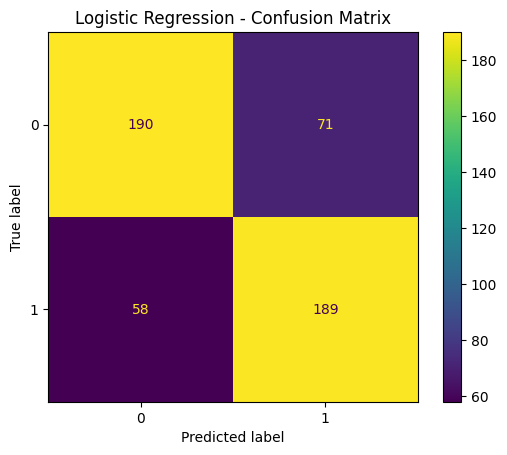

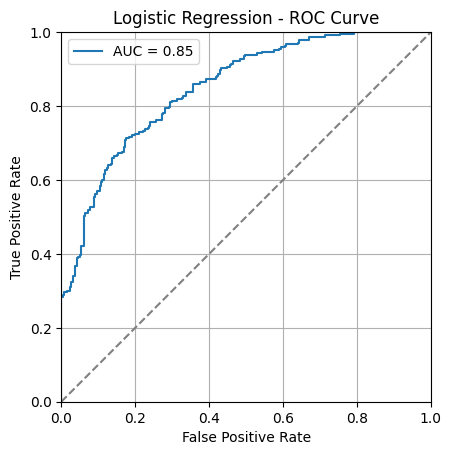

2026/03/13 02:36:40 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/13 02:36:40 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


<Figure size 640x480 with 0 Axes>


Decision Tree Accuracy: 0.7539370078740157
Decision Tree Precision: 0.7420634920634921
Decision Tree Recall: 0.757085020242915
Decision Tree F1 Score: 0.749498997995992
Decision Tree ROC-AUC: 0.82804380535778
Decision Tree Log Loss: 1.0943595437636962


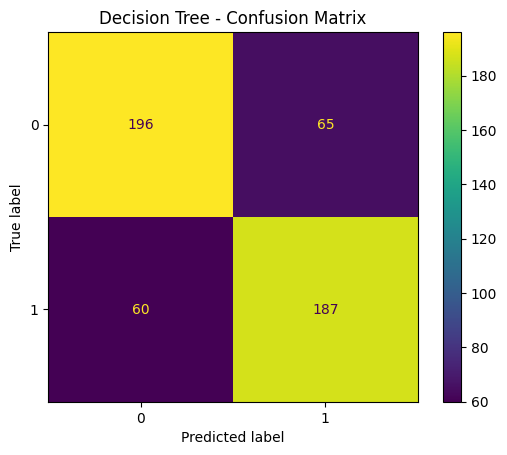

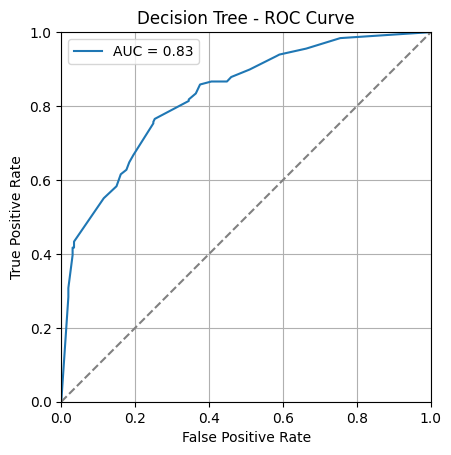

2026/03/13 02:36:53 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/13 02:36:53 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


<Figure size 640x480 with 0 Axes>


Random Forest Accuracy: 0.7421259842519685
Random Forest Precision: 0.7196969696969697
Random Forest Recall: 0.7692307692307693
Random Forest F1 Score: 0.7436399217221135
Random Forest ROC-AUC: 0.8486047124885601
Random Forest Log Loss: 0.47425276351291923


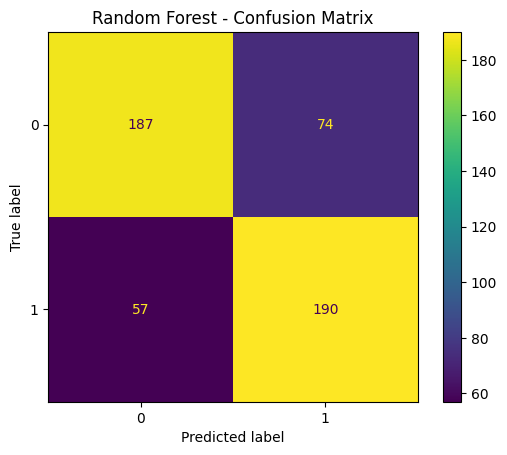

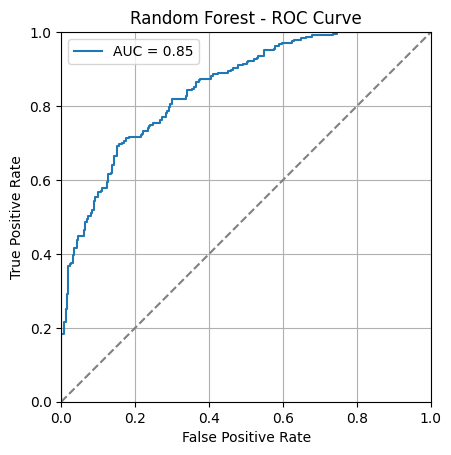

2026/03/13 02:37:32 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/13 02:37:32 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


<Figure size 640x480 with 0 Axes>


Gradient Boosting Machine Accuracy: 0.7401574803149606
Gradient Boosting Machine Precision: 0.7203065134099617
Gradient Boosting Machine Recall: 0.7611336032388664
Gradient Boosting Machine F1 Score: 0.7401574803149606
Gradient Boosting Machine ROC-AUC: 0.8478446336885539
Gradient Boosting Machine Log Loss: 0.4882654146818609


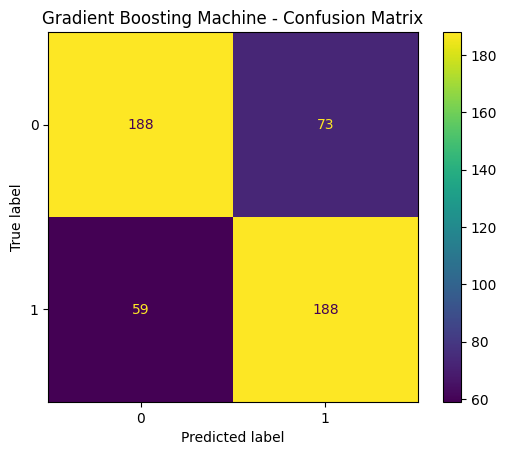

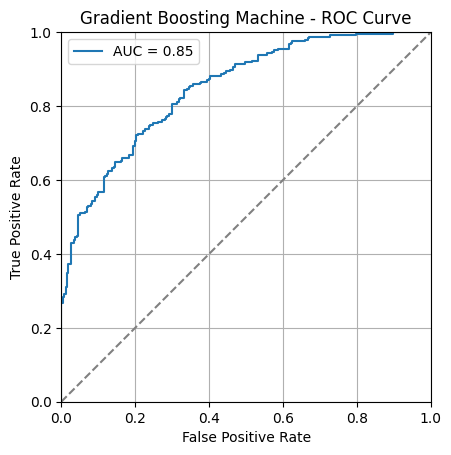

2026/03/13 02:38:13 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/13 02:38:13 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


<Figure size 640x480 with 0 Axes>

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [02:38:24] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



XGBoost Accuracy: 0.7401574803149606
XGBoost Precision: 0.7137546468401487
XGBoost Recall: 0.7773279352226721
XGBoost F1 Score: 0.7441860465116279
XGBoost ROC-AUC: 0.8426792002109607
XGBoost Log Loss: 0.5014532438262513


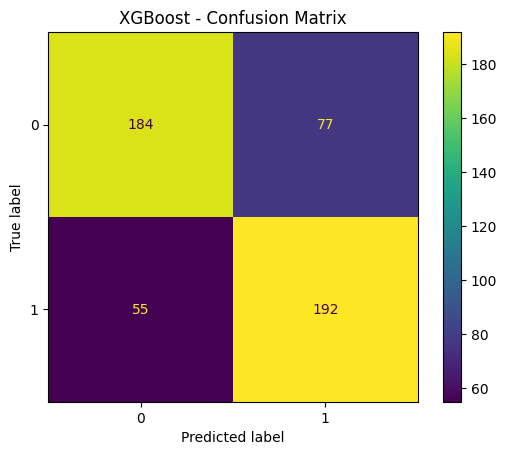

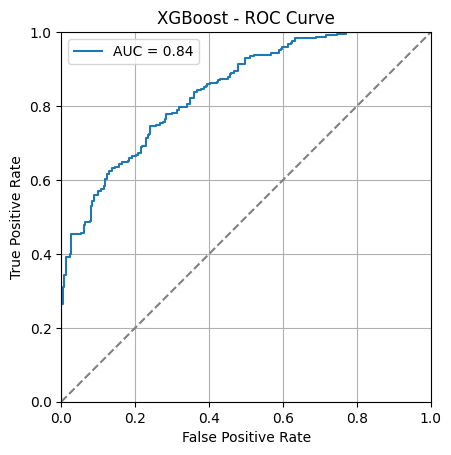

2026/03/13 02:38:25 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/13 02:38:25 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


<Figure size 640x480 with 0 Axes>

[LightGBM] [Info] Number of positive: 1021, number of negative: 1007
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000616 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3033
[LightGBM] [Info] Number of data points in the train set: 2028, number of used features: 23
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.503452 -> initscore=0.013807
[LightGBM] [Info] Start training from score 0.013807


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



LightGBM Accuracy: 0.734251968503937
LightGBM Precision: 0.7121212121212122
LightGBM Recall: 0.7611336032388664
LightGBM F1 Score: 0.735812133072407
LightGBM ROC-AUC: 0.8377154202925527
LightGBM Log Loss: 0.5652738282351414


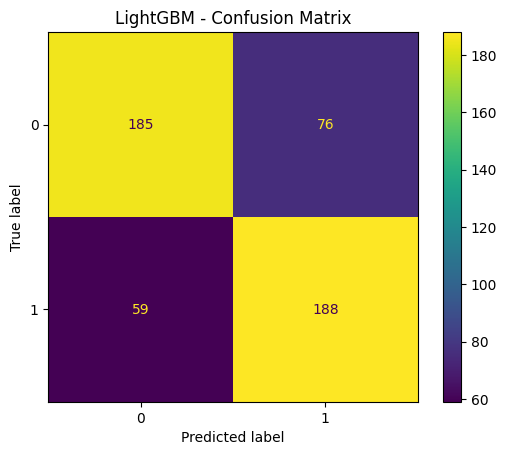

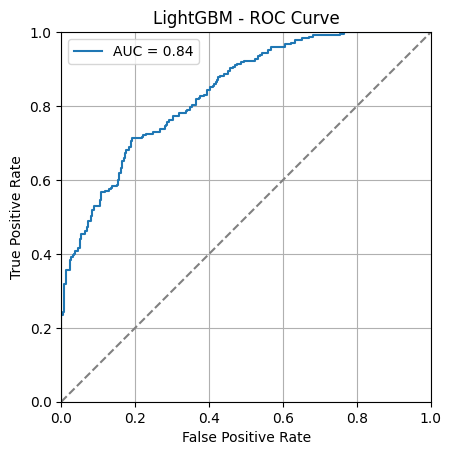

2026/03/13 02:38:40 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/13 02:38:40 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


<Figure size 640x480 with 0 Axes>


CatBoost Accuracy: 0.7440944881889764
CatBoost Precision: 0.7174721189591078
CatBoost Recall: 0.7813765182186235
CatBoost F1 Score: 0.748062015503876
CatBoost ROC-AUC: 0.8459211689701709
CatBoost Log Loss: 0.5154253769505781


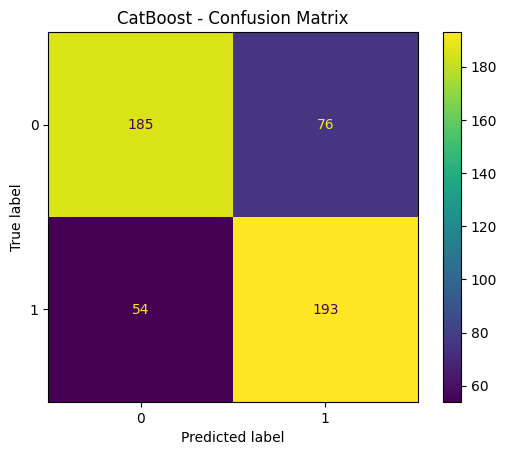

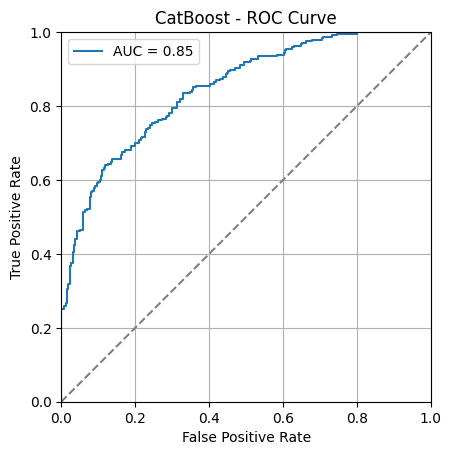

2026/03/13 02:39:33 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/13 02:39:33 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


In [ ]:
models = {
    "Logistic Regression": lr,
    "Decision Tree": dt,
    "Random Forest": rf,
    "Gradient Boosting Machine": gb,
    "XGBoost": xgb,
    "LightGBM": lgbm,
    "CatBoost": cat
}

cv = 5
strat = StratifiedKFold(n_splits=cv, shuffle=True, random_state=42)

mlflow.set_tracking_uri("sqlite:///:memory:")
mlflow.set_experiment("Model Training with Cross Validation")

# Validation parameter per model
validation_params = {
    "Logistic Regression": ("model__C", np.logspace(-2, 2, 5)),
    "Decision Tree": ("model__max_depth", [3, 5, 7, 9, None]),
    "Random Forest": ("model__n_estimators", [100, 200, 300, 500]),
    "Gradient Boosting Machine": ("model__n_estimators", [100, 200, 300, 500]),
    "XGBoost": ("model__n_estimators", [100, 200, 300, 500]),
    "LightGBM": ("model__n_estimators", [100, 200, 300, 500]),
    "CatBoost": ("model__iterations", [200, 300, 500, 700])
}

for name, model in models.items():

    with mlflow.start_run(run_name=f"{name}_Full_Evaluation"):

        cv_auc = cross_val_score(
            model,
            X_train,
            y_train,
            cv=strat,
            scoring="roc_auc",
            n_jobs=-1
        )

        mlflow.log_metric("cv_auc_mean", cv_auc.mean())
        mlflow.log_metric("cv_auc_std", cv_auc.std())

        param_name, param_range = validation_params[name]

        train_scores, val_scores = validation_curve(
            model,
            X_train,
            y_train,
            param_name=param_name,
            param_range=param_range,
            cv=strat,
            scoring="roc_auc",
            n_jobs=-1
        )

        train_mean = train_scores.mean(axis=1)
        val_mean = val_scores.mean(axis=1)

        fig_val, ax_val = plt.subplots()
        ax_val.plot(param_range, train_mean, marker='o', label="Train AUC")
        ax_val.plot(param_range, val_mean, marker='o', label="Validation AUC")
        ax_val.set_xlabel(param_name)
        ax_val.set_ylabel("ROC-AUC")
        ax_val.set_title(f"{name} - Validation Curve")
        ax_val.legend()

        mlflow.log_figure(fig_val, "validation_curve.png")
        plt.close(fig_val)
        plt.savefig(f"{name}_Validation_Curve.png")
        plt.show()


        model.fit(X_train, y_train)

        y_pred = model.predict(X_test)
        y_proba = model.predict_proba(X_test)[:, 1]

        accuracy = accuracy_score(y_test, y_pred)
        precision = precision_score(y_test, y_pred)
        recall = recall_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred)
        roc_auc = roc_auc_score(y_test, y_proba)
        ll = log_loss(y_test, y_proba)

        mlflow.log_metric("accuracy", accuracy)
        mlflow.log_metric("precision", precision)
        mlflow.log_metric("recall", recall)
        mlflow.log_metric("f1", f1)
        mlflow.log_metric("roc_auc", roc_auc)
        mlflow.log_metric("log_loss", ll)
        print(f"\n{name} Accuracy: {accuracy}")
        print(f"{name} Precision: {precision}")
        print(f"{name} Recall: {recall}")
        print(f"{name} F1 Score: {f1}")
        print(f"{name} ROC-AUC: {roc_auc}")
        print(f"{name} Log Loss: {ll}")


        cm = confusion_matrix(y_test, y_pred)
        disp = ConfusionMatrixDisplay(confusion_matrix=cm)
        disp.plot()
        plt.title(f"{name} - Confusion Matrix")
        plt.savefig(f"{name}_Confusion_Matrix.png")
        plt.show()

        fig_cm, ax_cm = plt.subplots()
        disp.plot(ax=ax_cm)
        ax_cm.set_title(f"{name} - Confusion Matrix")

        mlflow.log_figure(fig_cm, "confusion_matrix.png")
        plt.close(fig_cm)


        fpr, tpr, _ = roc_curve(y_test, y_proba)

        fig_roc, ax_roc = plt.subplots()
        RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=roc_auc).plot(ax=ax_roc)
        ax_roc.set_title(f"{name} - ROC Curve")
        ax_roc.plot([0, 1], [0, 1], linestyle='--', color='gray')
        ax_roc.set_xlabel("False Positive Rate")
        ax_roc.set_ylabel("True Positive Rate")
        ax_roc.legend()
        ax_roc.grid(True)
        ax_roc.set_aspect('equal')
        ax_roc.set_xlim([0, 1])
        ax_roc.set_ylim([0, 1])
        ax_roc.set_title(f"{name} - ROC Curve")
        plt.savefig(f"{name}_ROC_Curve.png")
        plt.show()

        mlflow.log_figure(fig_roc, "roc_curve.png")
        plt.close(fig_roc)


        mlflow.sklearn.log_model(model, "model")
        joblib.dump(model, f"{name}_model.pkl")

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


accuracy: 0.7500
precision: 0.7256
recall: 0.7814
f1: 0.7524
roc_auc: 0.8485
log_loss: 0.4831

Voting Ensemble Accuracy: 0.7500



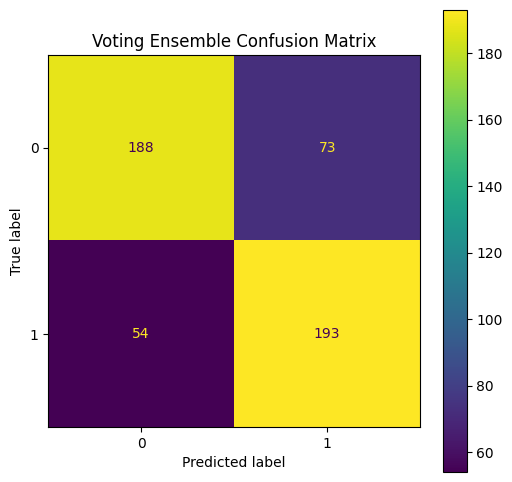

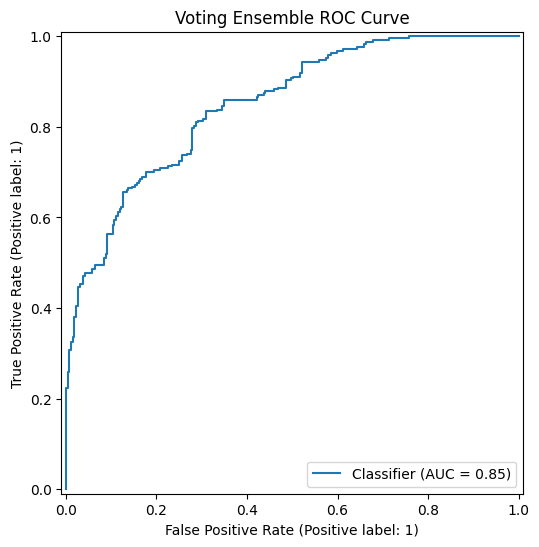

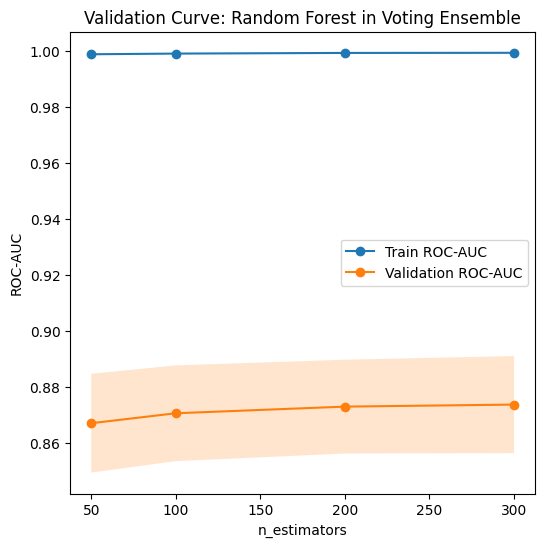

2026/03/13 02:39:55 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


In [ ]:
voting_clf = VotingClassifier(
    estimators=[
        ("lr", lr),
        ("rf", rf),
        ("gb", gb),
        ("xgb", xgb),
        ("lgbm", lgbm),
        ("cat", cat)
    ],
    voting="soft",
    n_jobs=-1
)

mlflow.set_experiment("Voting Ensemble Evaluation")
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

with mlflow.start_run(run_name="Voting_Ensemble"):

    # Fit ensemble
    voting_clf.fit(X_train, y_train)

    # Predict
    y_pred = voting_clf.predict(X_test)
    y_proba = voting_clf.predict_proba(X_test)[:, 1]


    metrics = {
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred),
        "recall": recall_score(y_test, y_pred),
        "f1": f1_score(y_test, y_pred),
        "roc_auc": roc_auc_score(y_test, y_proba),
        "log_loss": log_loss(y_test, y_proba)
    }

    for k, v in metrics.items():
        print(f"{k}: {v:.4f}")
        mlflow.log_metric(k, v)

    # Print Accuracy explicitly
    print(f"\nVoting Ensemble Accuracy: {metrics['accuracy']:.4f}\n")


    cm_fig, cm_ax = plt.subplots(figsize=(6,6))
    ConfusionMatrixDisplay.from_predictions(y_test, y_pred, ax=cm_ax)
    cm_ax.set_title("Voting Ensemble Confusion Matrix")
    plt.show()  # display inline
    mlflow.log_figure(cm_fig, "confusion_matrix.png")
    plt.close(cm_fig)


    roc_fig, roc_ax = plt.subplots(figsize=(6,6))
    RocCurveDisplay.from_predictions(y_test, y_proba, ax=roc_ax)
    roc_ax.set_title("Voting Ensemble ROC Curve")
    plt.show()  # display inline
    mlflow.log_figure(roc_fig, "roc_curve.png")
    plt.close(roc_fig)


    param_range = [50, 100, 200, 300]
    rf_estimator = voting_clf.estimators_[1][1]  # RandomForest inside Voting

    train_scores, val_scores = validation_curve(
        rf_estimator,
        X_train, y_train,
        param_name="n_estimators",
        param_range=param_range,
        cv=cv,
        scoring="roc_auc",
        n_jobs=-1
    )

    train_mean = train_scores.mean(axis=1)
    val_mean = val_scores.mean(axis=1)

    vc_fig, vc_ax = plt.subplots(figsize=(6,6))
    vc_ax.plot(param_range, train_mean, marker='o', label="Train ROC-AUC")
    vc_ax.plot(param_range, val_mean, marker='o', label="Validation ROC-AUC")
    vc_ax.fill_between(param_range, train_mean-train_scores.std(axis=1), train_mean+train_scores.std(axis=1), alpha=0.2)
    vc_ax.fill_between(param_range, val_mean-val_scores.std(axis=1), val_mean+val_scores.std(axis=1), alpha=0.2)
    vc_ax.set_xlabel("n_estimators")
    vc_ax.set_ylabel("ROC-AUC")
    vc_ax.set_title("Validation Curve: Random Forest in Voting Ensemble")
    vc_ax.legend()
    plt.show()  # display inline
    mlflow.log_figure(vc_fig, "validation_curve_rf.png")
    plt.close(vc_fig)


    mlflow.sklearn.log_model(voting_clf, name="voting_ensemble_model")

In [ ]:
!zip -r mlruns.zip /content/mlruns

updating: content/mlruns/ (stored 0%)
updating: content/mlruns/1/ (stored 0%)
updating: content/mlruns/1/44925bc8640b460585aea34e186ed774/ (stored 0%)
updating: content/mlruns/1/44925bc8640b460585aea34e186ed774/artifacts/ (stored 0%)
updating: content/mlruns/1/44925bc8640b460585aea34e186ed774/artifacts/confusion_matrix.png (deflated 14%)
updating: content/mlruns/1/44925bc8640b460585aea34e186ed774/artifacts/roc_curve.png (deflated 9%)
updating: content/mlruns/1/44925bc8640b460585aea34e186ed774/artifacts/validation_curve.png (deflated 11%)
updating: content/mlruns/1/4f35439ad147410184f67cada1fcb1e0/ (stored 0%)
updating: content/mlruns/1/4f35439ad147410184f67cada1fcb1e0/artifacts/ (stored 0%)
updating: content/mlruns/1/4f35439ad147410184f67cada1fcb1e0/artifacts/confusion_matrix.png (deflated 13%)
updating: content/mlruns/1/4f35439ad147410184f67cada1fcb1e0/artifacts/roc_curve.png (deflated 11%)
updating: content/mlruns/1/4f35439ad147410184f67cada1fcb1e0/artifacts/validation_curve.png (def

In [ ]:
!zip -r catboost_info.zip /content/catboost_info

updating: content/catboost_info/ (stored 0%)
updating: content/catboost_info/tmp/ (stored 0%)
updating: content/catboost_info/learn/ (stored 0%)
updating: content/catboost_info/learn/events.out.tfevents (deflated 77%)
updating: content/catboost_info/learn_error.tsv (deflated 54%)
updating: content/catboost_info/catboost_training.json (deflated 76%)
updating: content/catboost_info/time_left.tsv (deflated 51%)


In [ ]:
test_df.shape

(258131, 23)

In [ ]:
X.columns

Index(['Season', 'Team1ID', 'Team2ID', 'Team1Name', 'Team2Name',
       'Team1_WinPct', 'Team1_AvgPointsFor', 'Team1_AvgPointsAgainst',
       'Team1_PointDiff', 'Team1_NumGames', 'Team1_Seed', 'Team2_WinPct',
       'Team2_AvgPointsFor', 'Team2_AvgPointsAgainst', 'Team2_PointDiff',
       'Team2_NumGames', 'Team2_Seed', 'H2H_Team1Wins', 'H2H_Team2Wins',
       'Diff_WinPct', 'Diff_PointDiff', 'Diff_Seed', 'SameConference'],
      dtype='object')

In [ ]:
#Okay, lets predict it my guy (I'm Choosing My Voting Ensemble, since the more the estimators, the more the decisio is averaged out)
imputer = SimpleImputer(strategy="median")
test_df = imputer.fit_transform(test_df)
preds = voting_clf.predict(test_df)

submission = pd.DataFrame({
    "ID": ids,
    "Result": preds
})

submission.to_csv("Female_Submission.csv", index=False)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ut

In [ ]:
#Now WE merge predictions
sub_1 = pd.read_csv("/content/Male_Submission.csv")
sub_1["ID"] = sub_1["Id"]
sub_1 = sub_1.drop(columns=["Id"])
sub_1 = sub_1[["ID", "Result"]]
sub_2 = pd.read_csv("/content/Female_Submission.csv")

submission = pd.concat([sub_1, sub_2], ignore_index=True)
submission["Pred"] = submission["Result"]

In [ ]:

submission = submission.drop("Result", axis=1)

submission.to_csv("submission_final.csv", index=False)

In [ ]:
sub = pd.read_csv("/content/submission_final (1).csv")
sub_id = submission[submission['ID'].str.startswith('2026', na=False)]
sub_id

,ID,Pred
0,2026_1101_1102,0
1,2026_1101_1103,0
2,2026_1101_1104,0
3,2026_1101_1105,1
4,2026_1101_1106,1
...,...,...
129236,2026_3474_3476,0
129237,2026_3474_3477,0
129238,2026_3475_3476,1
129239,2026_3475_3477,1


In [ ]:
sample = pd.read_csv('/content/drive/MyDrive/march-machine-learning-mania-2026/SampleSubmissionStage2.csv')  # or Stage2
print(f"Sample submission: {len(sample)} rows")

Sample submission: 132133 rows


In [ ]:
sample_ids = set(sample['ID'])
your_ids = set(sub['ID'])

missing_ids = your_ids - sample_ids
extra_ids = your_ids - sample_ids

In [ ]:
len(missing_ids)

519144